## **Importação das bibliotecas e dados (AEP e Duas Unas)**

In [33]:
# %pip install ipykernel --break-system-packages
# %pip install scikit-learn --break-system-packages
# %pip install matplotlib --break-system-packages
# %pip install keras --break-system-packages
# %pip install tensorflow --break-system-packages
# %pip install pandas --break-system-packages
# %pip install plotly --break-system-packages
# %pip install seaborn --break-system-packages
# %pip install nbformat --break-system-packages
# %pip install keras --break-system-packages
# %pip install pswarm


In [34]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.initializers import GlorotUniform    #Inicializador de pesos
from sklearn.model_selection import KFold
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from keras.activations import relu
from keras.initializers import GlorotUniform
from keras.initializers import GlorotNormal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf #Biblioteca para machine learning

In [35]:

base_path = './dataset/'

# carregando arquivo CSV
time_base = 'days'  # Escolha do tipo de agrupamento
duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_1_{time_base}.csv'  # Definição do caminho do diretório do dataset

validation_interval = 91 # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
time_step = 1  # Number of previous time steps to consider
output_steps = 90  # Number of future steps to predict

# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset

duas_unas_validation = duas_unas_df.tail(validation_interval)  # Criação do dataset de validação

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação
duas_unas_df = duas_unas_df.drop(indices_to_validate).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

duas_unas_df['timestamp'] = pd.to_datetime(duas_unas_df['timestamp'])  # Transformação dos dados da coluna 'timestamp' no formato datetime. Ela lida com vários formatos de data/hora e tenta interpretá-los de forma inteligente.
duas_unas_validation['timestamp'] = pd.to_datetime(duas_unas_validation['timestamp'])  # Idem da ação da linha de cima.

duas_unas_df['index'] = range(len(duas_unas_df))  # Criação da coluna 'index' em que os valores vão de zero ao tamanho total do daframe
duas_unas_validation['index'] = indices_to_validate  # Idem da acima da linha acima
#print(indices_to_validate)
duas_unas_df['kwh'] = duas_unas_df['kWh fornecido']  # Criação da coluna 'kwh' que copia os dados da coluna 'kWh fornecido'
duas_unas_validation['kwh'] = duas_unas_validation['kWh fornecido']  # Idem da acima da linha acima

duas_unas_df.drop(columns=['timestamp'], inplace=True)  # Remoção da coluna 'timestamp', inclusive no dataframe original
duas_unas_validation.drop(columns=['timestamp'], inplace=True)  # Idem da acima da linha acima

duas_unas_df.drop(columns=['kWh fornecido'], inplace=True)  # Remoção da coluna 'kWh fornecido', inclusive no dataframe original
duas_unas_validation.drop(columns=['kWh fornecido'], inplace=True)  # Idem da acima da linha acima
print(duas_unas_df)
# X = duas_unas_df['index'].values.reshape(-1,1)  # Cria o array X com os índices do dataframe duas_unas_df
# y = duas_unas_df['kwh'].values  # Cria o array y com os dados de energia de duas_unas_df
# #print(y)
# X_validation = duas_unas_validation['index'].values.reshape(-1,1)  # Cria o array X_validation com os índices do dataframe duas_unas_validation
# y_validation = duas_unas_validation['kwh'].values  # Cria o array y com os dados de energia de duas_unas_validation
# #print(X_validation)

     index       kwh
0        0      0.00
1        1      0.00
2        2      0.00
3        3      0.00
4        4  10827.36
..     ...       ...
215    215  19992.96
216    216  20116.44
217    217  20214.72
218    218  20208.24
219    219  17891.64

[220 rows x 2 columns]


In [36]:
import tensorflow as tf

def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

    #     # Verificação para o primeiro elemento
    #     first_idx = 0
    #     first_elem = tf.gather(y_test, first_idx)
    #     second_elem = tf.gather(y_test, first_idx + 1)
    #     third_elem = tf.gather(y_test, first_idx + 2)

    #     # Atualiza o peso do primeiro elemento
    #     first_weight_update = tf.where(
    #         (first_elem < second_elem) & (first_elem < third_elem) |
    #         (first_elem > second_elem) & (first_elem > third_elem),
    #         3.0,
    #         weights_updated[first_idx]
    #     )
    #     weights_updated = tf.tensor_scatter_nd_update(weights_updated, [[first_idx]], [first_weight_update])


    #     # Verificação para o último elemento
    #     last_idx = tf.shape(y_test)[0] - 1
    #     last_elem = tf.gather(y_test, last_idx)
    #     second_last_elem = tf.gather(y_test, last_idx - 1)
    #     third_last_elem = tf.gather(y_test, last_idx - 2)

    # # Atualiza o peso do último elemento
    #     last_weight_update = tf.where(
    #         (last_elem < second_last_elem) & (last_elem < third_last_elem) |
    #         (last_elem > second_last_elem) & (last_elem > third_last_elem),
    #         3.0,
    #         weights_updated[last_idx]
    #     )
    #     weights_updated = tf.tensor_scatter_nd_update(weights_updated, [[last_idx]], [last_weight_update])

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [37]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [38]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X, y = [], []  # Criação das listas
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data[i:(i + time_step), 0])  # Construção do dataset 
        y.append(data[(i + time_step):(i + time_step + output_steps), 0])
    return np.array(X), np.array(y)

In [39]:
def avaliacao_multistep(janela_real, janela_prevista):

    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    janela_real = np.array(janela_real)
    janela_prevista = np.array(janela_prevista)

    print(janela_real[0])
    
    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0
    # Converte as listas para arrays NumPy
    #janela_real = np.array(janela_real)
    #janela_prevista = np.array(janela_prevista)

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)
    # print(f"dif_perc",diferencas_percentuais)
    # print("len(janela_real)",len(janela_real))

    # Conta quantas diferenças percentuais estão dentro da tolerância
    acertos = np.sum(diferencas_percentuais <= 0.05) #0.05 é a tolerância

    # Calcula a acurácia
    acuracia = acertos / len(janela_real)   
    acuracia = round(100 * acuracia, 2)
            
    print("Accuracy Score of LSTM model = ",acuracia)
    
    # mae_med += mae
    # mse_med += mse
    # rmse_med += rmse
    # mape_med += mape
    # acuracia_med += acuracia
            
    # mae_med = mae_med/(len(janela_prevista))
    # mse_med /=(len(janela_prevista))
    # rmse_med /=(len(janela_prevista))
    # mape_med /=(len(janela_prevista))
    # acuracia_med /=(len(janela_prevista))
    
    return round(mae,2), round(mse,2), round(rmse,2), round(mape,2), round(acuracia,2)

In [40]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados
scaled_kwh = scaler.fit_transform(duas_unas_df['kwh'].values.reshape(-1, 1))  # padronização de duas_unas_df

scaled_kwh_validation = scaler.fit_transform(duas_unas_validation['kwh'].values.reshape(-1,1))  # padronização de duas_unas_validacao

# Create the dataset
X, y = create_dataset(scaled_kwh, time_step, output_steps)
X_validation, y_validation = create_dataset(scaled_kwh_validation, time_step, output_steps)
print(f"X_validation", X_validation)
print(f"y_validation", y_validation)
# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)
X_validation = X_validation.reshape(X_validation.shape[0], X_validation.shape[1], 1)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_test.shape)
print(y_test.shape)

print(f"X_test", X_test)
print(f"y_test", y_test)

X_validation [[0.73668494]]
y_validation [[0.72420007 0.72726337 0.71779031 0.72175458 0.72651685 0.72855047
  0.73027518 0.         0.92673823 0.92859165 0.93322522 0.93649445
  0.93515587 0.93016192 0.8772106  0.92848869 0.92601745 0.91294051
  0.93649445 0.9378073  0.92632636 0.91852653 0.9186295  0.91741962
  0.91659588 0.91541174 0.91340387 0.91214251 0.88835689 0.92277396
  0.93646871 0.93528458 0.93829639 0.9442428  0.94434577 0.92179576
  0.95466831 0.95544057 0.95477128 0.95433367 0.95109017 0.95191392
  0.95132185 0.85265271 0.93126882 0.90650501 0.92727881 0.92781939
  0.92709862 0.95670193 0.96383247 0.96403841 0.96403841 0.96241666
  0.96223647 0.9608464  0.32180091 0.95945633 0.99441398 0.99477437
  0.99062991 0.98893093 0.77102479 0.99770896 0.95492573 0.96532551
  0.72692872 0.4970268  0.99304966 0.98996061 0.99093881 0.99104178
  0.99065565 0.99006358 0.99454269 0.78937885 0.99817232 0.99794064
  0.92300564 1.         0.99945942 0.99858419 0.99740006 0.99469715
  0.993

In [41]:
def main_looping(output_steps, X_train, y_train, X_validation, y_validation):


    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(75, return_sequences=True, input_shape=(X_train.shape[1], 1),
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.4))
    model.add(LSTM(75, return_sequences=True,
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.4))
    model.add(LSTM(75, return_sequences=True,
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.4))
    model.add(LSTM(75, return_sequences=False,
                        kernel_initializer=GlorotUniform(),     # Inicializa os pesos
                        recurrent_initializer=GlorotUniform(),  # Inicializa os pesos recorrentes
                        bias_initializer=GlorotUniform()))       # Inicializa os bias
    model.add(Dropout(0.4))
    model.add(Dense(output_steps, activation="relu",kernel_initializer=GlorotUniform()))

    learning_rate = 0.005
    optimizer = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss=wmae)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=8, restore_best_weights=True)
    #callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.02, patience=2, verbose=0, mode='auto')
    history = model.fit(X_train, y_train, epochs=10000, batch_size=45, validation_data=(X_test, y_test), callbacks=[early_stopping])
    # Train the model
    #history = model.fit(X_train, y_train, epochs=1000, batch_size=4, verbose=1, callbacks=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, verbose=1))

    # Plotar as perdas de treinamento e validação
    plt.plot(history.history['loss'], label='Loss de Treinamento')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()

    return model

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 520ms/step - loss: 0.9337 - val_loss: 0.8902
Epoch 2/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8798 - val_loss: 0.8208
Epoch 3/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8105 - val_loss: 0.7235
Epoch 4/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.7047 - val_loss: 0.5777
Epoch 5/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5515 - val_loss: 0.3198
Epoch 6/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2808 - val_loss: 0.1266
Epoch 7/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1589 - val_loss: 0.0990
Epoch 8/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1484 - val_loss: 0.0824
Epoch 9/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1445 - val_loss: 0.0761
Epoch 10/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1327 - val_loss: 0.0982
Epoch 11/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1383 - val_loss: 0.1209
Epoch 12/10000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/ste

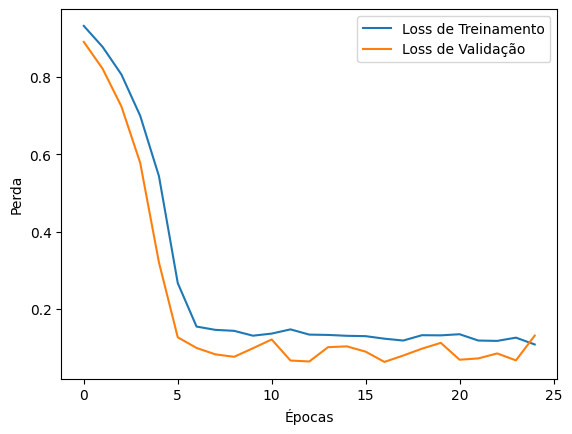

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step


In [42]:
iter_prev = []
rep = 1
for i in range(rep):
    model = main_looping(output_steps, X_train, y_train, X_test, y_test)
    #print(f"X_validation", X_validation)
    y_pred = model.predict(X_validation)
    y_pred_rescaled = scaler.inverse_transform(y_pred)
    #print(f"y_pred_rescaled",y_pred_rescaled)
    iter_prev.append(y_pred_rescaled)

In [43]:
# # print(iter_prev[4][0][0])
# # print(len(iter_prev[0][0]))
# iter_prev[4][0][11]

In [44]:
# print(X_validation)
# print(iter_prev[0][0])
med =[]
soma = 0
media = 0
for j in range(len(iter_prev[0][0])):
    for i in range(rep):
        soma += iter_prev[i][0][j]
    media = soma/rep
    med.append(media)
    soma = 0
    media = 0
        

In [45]:
med

[22137.484375,
 22315.404296875,
 22092.640625,
 21290.435546875,
 22890.84375,
 21913.560546875,
 22091.470703125,
 21807.34375,
 23677.72265625,
 22889.025390625,
 22234.359375,
 23199.572265625,
 22987.646484375,
 23947.4921875,
 22138.416015625,
 23157.5546875,
 22108.51171875,
 22958.380859375,
 22816.94140625,
 22382.705078125,
 22323.6796875,
 22062.041015625,
 22329.185546875,
 22879.8828125,
 22999.353515625,
 22964.37109375,
 23889.107421875,
 23944.9765625,
 22227.001953125,
 23732.671875,
 23728.51953125,
 21955.908203125,
 23024.0234375,
 23297.84375,
 23144.341796875,
 22659.345703125,
 22860.693359375,
 23548.7890625,
 22244.640625,
 20973.21484375,
 21804.255859375,
 23052.576171875,
 23270.4375,
 22974.365234375,
 23928.248046875,
 23214.009765625,
 22214.451171875,
 22959.0703125,
 21729.107421875,
 23104.107421875,
 23083.298828125,
 22435.099609375,
 22812.591796875,
 22867.13671875,
 23086.791015625,
 23510.767578125,
 22183.64453125,
 21539.939453125,
 22752.31640

In [46]:
y_pred_med = np.mean(iter_prev)
print(y_pred_med)

22732.104


[220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310]
22732.10412326389


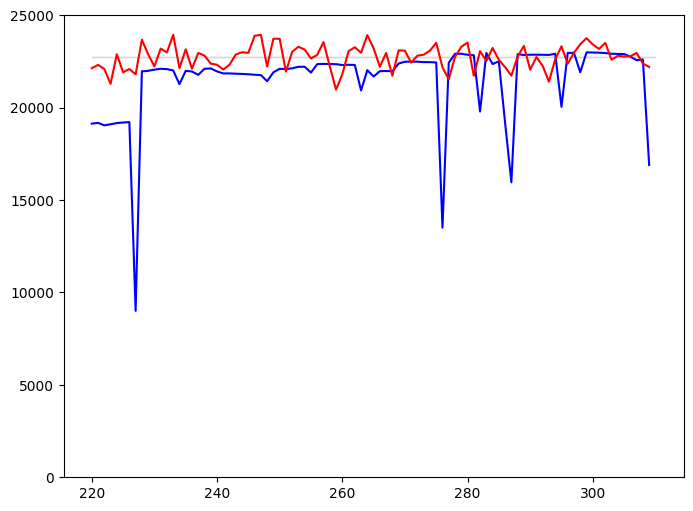

[19135.44]
MAE(Erro absoluto médio) Score of LSTM model =  1338.011
 
MSE(Erro quadrático médio) Score of LSTM model =  5120137.58
 
RMSE(Raiz do erro quadrático médio) Score of LSTM model =  2262.772
 
MAPE(Erro percentual médio absoluto) Score of LSTM model =  0.08
 
Accuracy Score of LSTM model =  65.56


(1338.01, 5120137.58, 2262.77, 0.08, 65.56)

In [47]:
# # Verifique os comprimentos das janelas
# print(f"Tamanho de y_test_rescaled: {len(y_test_rescaled)}")
# print(f"Tamanho de y_pred_rescaled: {len(med)}")
# y_pred = model.predict(X_validation)
# print(len(X_validation), len(y_pred), len(X_validation[0]))
# y_pred_rescaled = scaler.inverse_transform(y_pred)
med = np.array(med)
y_validation_reshaped = y_validation.reshape(-1, 1)
# y_test_rescaled = scaler.inverse_transform(y_validation)

y_test_rescaled = scaler.inverse_transform(y_validation_reshaped)
#indices_to_validate = indices_to_validate[:len(y_pred_rescaled)]
indices_to_validate = indices_to_validate[:validation_interval]
print(indices_to_validate)
means = np.mean(med)
stds = np.std(y_test_rescaled[0]) 
print(means) 

plt.figure(figsize=(8,6))
plt.plot(indices_to_validate[0:output_steps], y_test_rescaled, label="Original", color='blue')
plt.plot(indices_to_validate[0:output_steps], med, label="Predição", color='red')
plt.fill_between(indices_to_validate, means - stds, means + stds, color='gray', alpha=0.3, label=f'±1 Desvio Padrão ({stds:.2f})')
#plt.plot([indices_to_validate[0],indices_to_validate[12]], [means, means], color='yellow', linestyle='--', label=f'Média ({means:.2f})')
plt.yticks(np.arange(0,30000,step=5000))
plt.show()

# Adicionando uma nova dimensão
y_pred_2d = med.reshape(-1, 1)

# print("Tamanho de y_test_rescaled:", len(y_test_rescaled))
# print("Tamanho de med:", len(y_pred_2d))

# print("y_test_rescaled:", y_test_rescaled)
# print("y_pred_rescaled:", y_pred_2d)

avaliacao_multistep(y_test_rescaled,y_pred_2d)


In [48]:
# Melhor solução encontrada: [8.62753970e+01 4.69798652e-01 8.21933652e-03 1.15558296e+01
#  1.27279632e+02 3.18523512e+00 5.12027272e+00 7.84886166e-01
#  1.56826202e+00 1.59136446e+00]
# Melhor score: 0.0011546079767867923

